In [1]:
import pandas as pd

df = pd.read_csv("data/hr_data.csv")
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [ ]:
## check na and null values

print(df.isna().sum())
print(df.isnull().sum())



satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
high_salary              0
low_salary               0
dtype: int64
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
high_salary              0
low_salary               0
dtype: int64


In [ ]:
dummies = pd.get_dummies(df.salary)
dummies.head()
df = pd.concat([df, dummies], axis="columns")
df.head()
df.drop("salary", axis="columns", inplace=True)
df.head()





,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,high,low,medium
0,0.38,0.53,2,157,3,0,1,0,sales,False,True,False
1,0.80,0.86,5,262,6,0,1,0,sales,False,False,True
2,0.11,0.88,7,272,4,0,1,0,sales,False,False,True
3,0.72,0.87,5,223,5,0,1,0,sales,False,True,False
4,0.37,0.52,2,159,3,0,1,0,sales,False,True,False


In [ ]:
df.rename(columns={"high": "high_salary", "low": "low_salary"}, inplace=True)

In [22]:
df.drop("medium", axis="columns", inplace=True)

In [ ]:
df.head()
cols = ["high_salary", "low_salary"]  
df[cols] = df[cols].astype(int)


In [25]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,high_salary,low_salary
0,0.38,0.53,2,157,3,0,1,0,sales,0,1
1,0.80,0.86,5,262,6,0,1,0,sales,0,0
2,0.11,0.88,7,272,4,0,1,0,sales,0,0
3,0.72,0.87,5,223,5,0,1,0,sales,0,1
4,0.37,0.52,2,159,3,0,1,0,sales,0,1


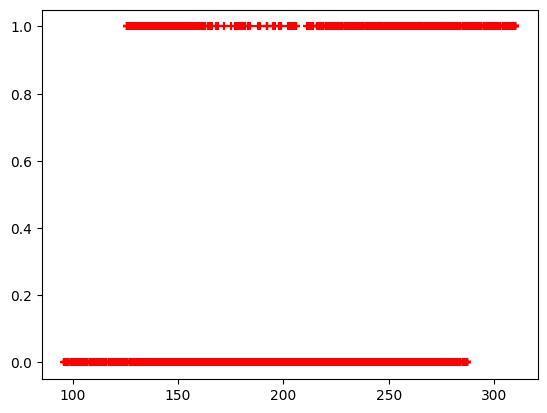

In [30]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.scatter(df.average_montly_hours, df.left, marker="+", color="red")




In [28]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,high_salary,low_salary
0,0.38,0.53,2,157,3,0,1,0,sales,0,1
1,0.80,0.86,5,262,6,0,1,0,sales,0,0
2,0.11,0.88,7,272,4,0,1,0,sales,0,0
3,0.72,0.87,5,223,5,0,1,0,sales,0,1
4,0.37,0.52,2,159,3,0,1,0,sales,0,1


In [31]:
x = df[["satisfaction_level", "last_evaluation", "average_montly_hours", "time_spend_company", "Work_accident", "promotion_last_5years", "high_salary", "low_salary"]]
x.head()

,satisfaction_level,last_evaluation,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,high_salary,low_salary
0,0.38,0.53,157,3,0,0,0,1
1,0.80,0.86,262,6,0,0,0,0
2,0.11,0.88,272,4,0,0,0,0
3,0.72,0.87,223,5,0,0,0,1
4,0.37,0.52,159,3,0,0,0,1


In [32]:
y = df.left

In [33]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [34]:
from sklearn.linear_model import LogisticRegression

hr_model = LogisticRegression()

hr_model.fit(x_train, y_train)

c:\Dev\gcp\venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [35]:
hr_model.predict(x_test)

array([0, 1, 0, ..., 0, 1, 0], shape=(3000,))

In [37]:
hr_model.score(x_test, y_test)



0.7653333333333333